In [1]:
import pandas as pd
import joblib

In [2]:
testing_results = pd.DataFrame({
    "Test No.": [1, 2, 3, 4, 5],
    "Input Changes": [
        "Default values",
        "Changed day, weather, and collision",
        "Changed vehicles, casualties, and movement",
        "Changed driver and vehicle details",
        "Multiple different inputs"
    ],
    "Predicted Severity": [
        "Fatal",
        "Fatal",
        "Fatal",
        "Fatal",
        "Fatal"
    ],
    "Status": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed"
    ]
})

testing_results

,Test No.,Input Changes,Predicted Severity,Status
0,1,Default values,Fatal,Passed
1,2,"Changed day, weather, and collision",Fatal,Passed
2,3,"Changed vehicles, casualties, and movement",Fatal,Passed
3,4,Changed driver and vehicle details,Fatal,Passed
4,5,Multiple different inputs,Fatal,Passed


In [3]:
testing_results.to_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\day19_streamlit_testing.csv",
    index=False
)

In [4]:
print("Day 19 testing report saved successfully!")

Day 19 testing report saved successfully!


In [5]:
model = joblib.load(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Model\accident_severity_model.pkl"
)

In [6]:
X = pd.read_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Dataset\X_prepared.csv"
)

In [7]:
predictions = model.predict(X)

print(predictions[:20])

[2 2 1 2 2 2 2 2 2 2 1 1 2 2 2 1 2 1 2 1]


In [8]:
import numpy as np

print(np.unique(predictions, return_counts=True))

(array([0, 1, 2], dtype=int64), array([  125,  1400, 10791], dtype=int64))


In [9]:
y_data = pd.read_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Dataset\Y_prepared.csv"
)

In [10]:
y = y_data["Accident_severity"]

In [11]:
predictions = model.predict(X)

In [12]:
print(pd.Series(predictions).value_counts())

2    10791
1     1400
0      125
Name: count, dtype: int64


In [13]:
print("Actual Class Distribution:")
print(y.value_counts())

print("\nPredicted Class Distribution:")
print(pd.Series(predictions).value_counts())

Actual Class Distribution:
Accident_severity
2    10415
1     1743
0      158
Name: count, dtype: int64

Predicted Class Distribution:
2    10791
1     1400
0      125
Name: count, dtype: int64


In [14]:
from sklearn.metrics import classification_report

In [16]:
print(
    classification_report(
        y,
        predictions,
        target_names=["Fatal", "Serious", "Slight"]
    )
)

              precision    recall  f1-score   support

       Fatal       1.00      0.79      0.88       158
     Serious       1.00      0.80      0.89      1743
      Slight       0.97      1.00      0.98     10415

    accuracy                           0.97     12316
   macro avg       0.99      0.86      0.92     12316
weighted avg       0.97      0.97      0.97     12316



In [17]:
from sklearn.metrics import confusion_matrix

In [18]:
cm = confusion_matrix(y, predictions)

print(cm)

[[  125     0    33]
 [    0  1399   344]
 [    0     1 10414]]


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

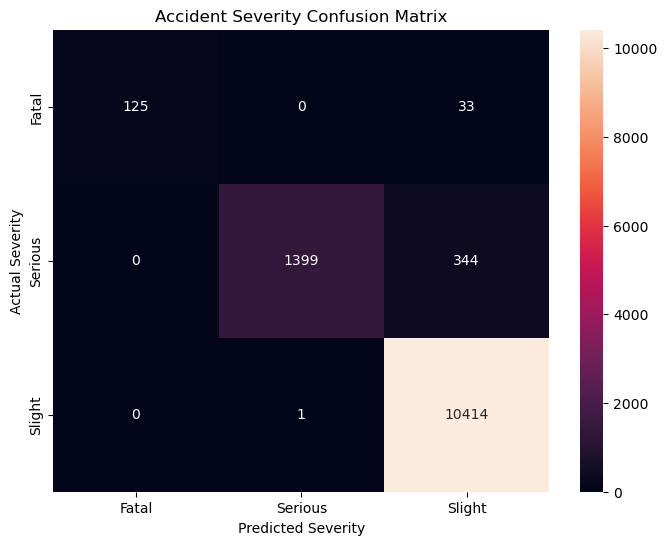

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fatal", "Serious", "Slight"],
    yticklabels=["Fatal", "Serious", "Slight"]
)

plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title("Accident Severity Confusion Matrix")

plt.show()

In [22]:
plt.savefig(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\confusion_matrix.png"
)

<Figure size 640x480 with 0 Axes>